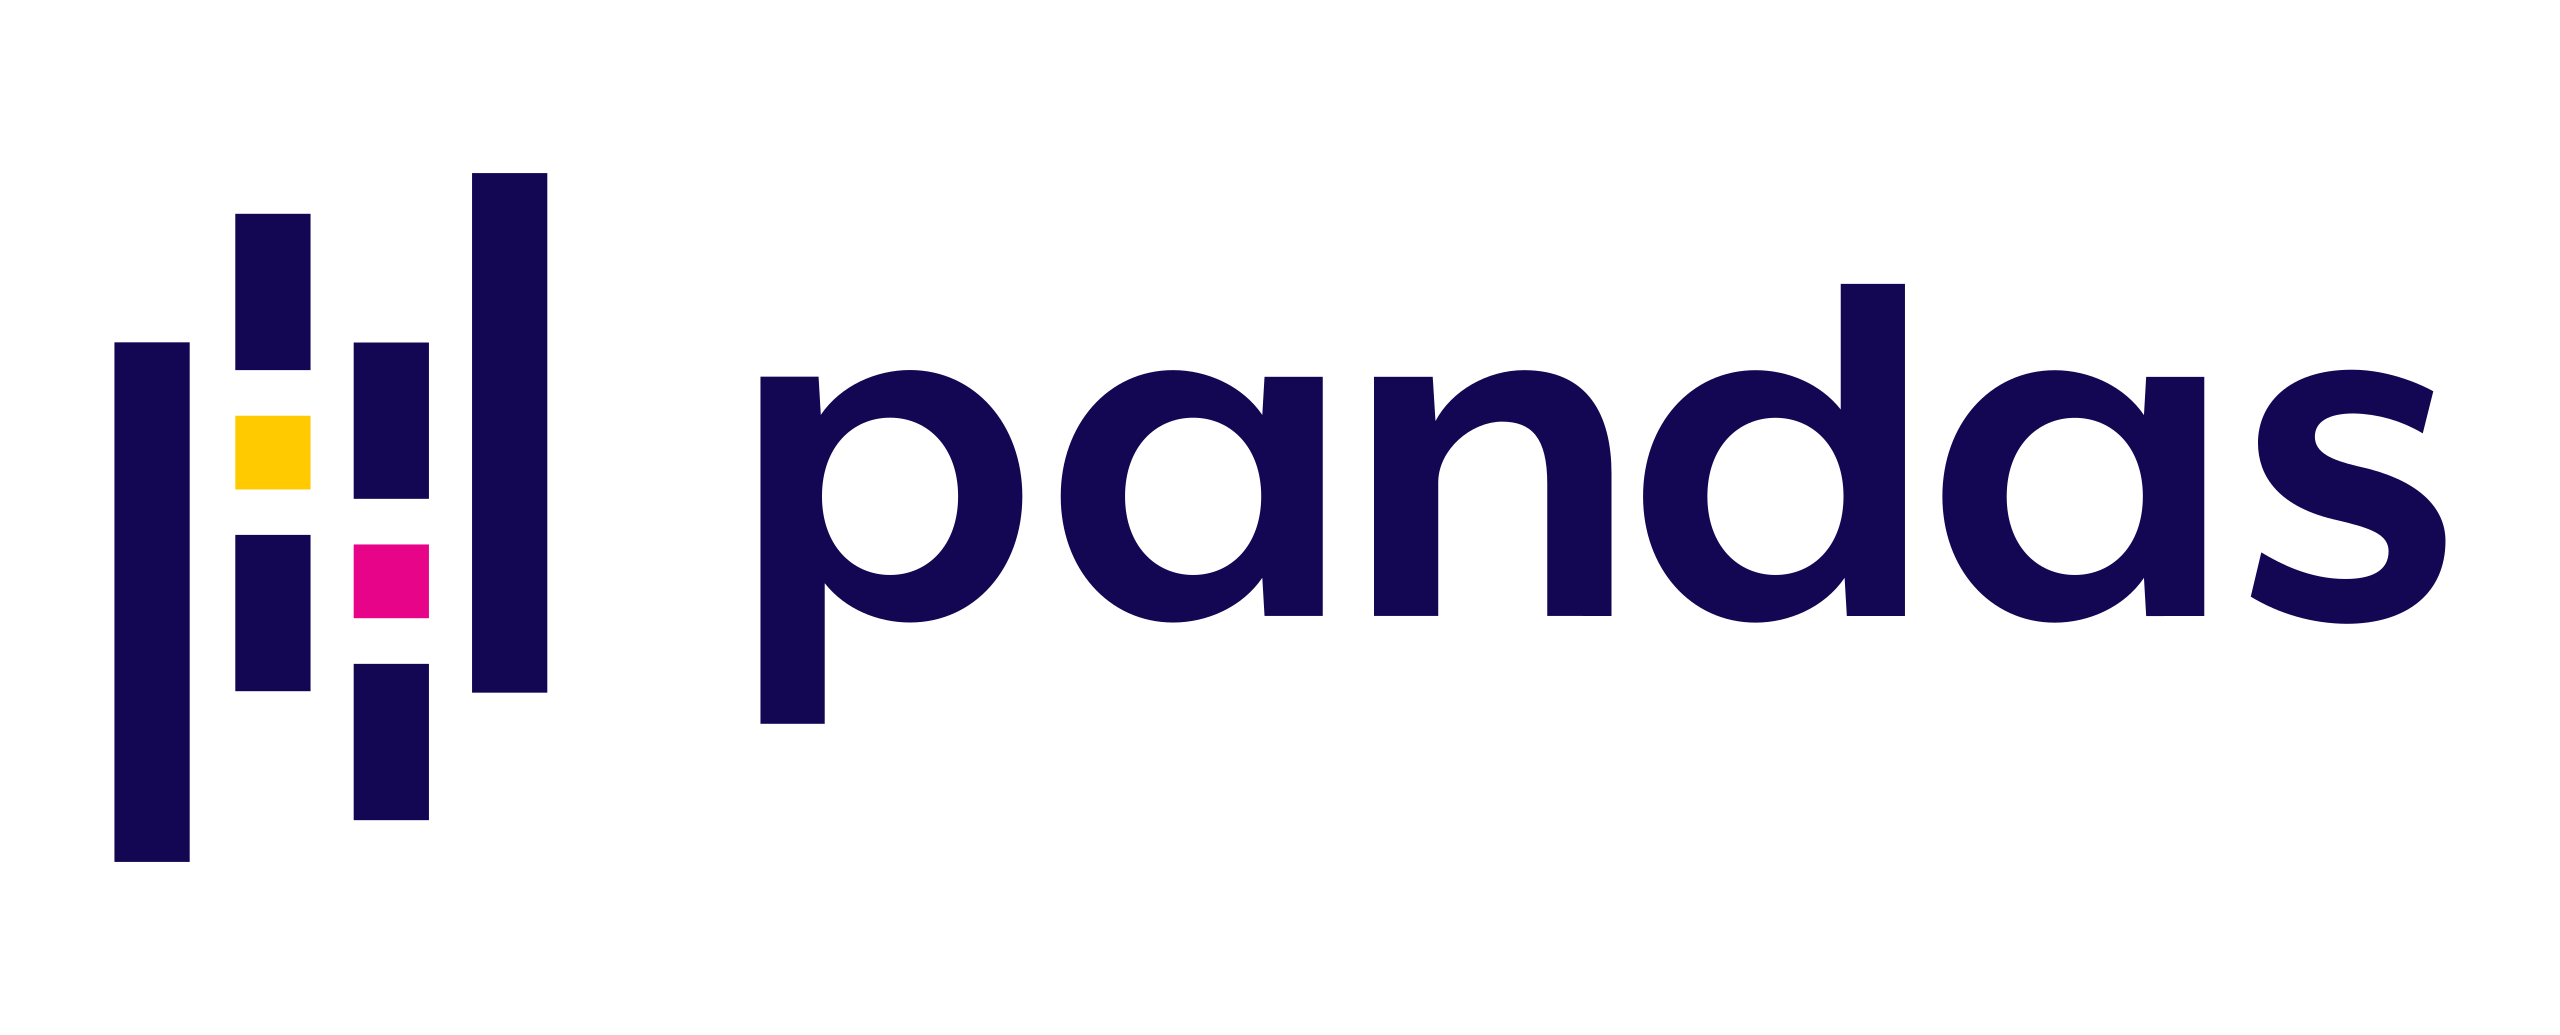

In [1]:
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt

In [2]:
df = pd.read_excel('./1-SEEG10_GERAL-BR_UF_2022.10.27-FINAL-SITE.xlsx', sheet_name = 'GEE Estados')
df

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Emissão / Remoção / Bunker,Gás,Estado,Atividade Econômica,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,Emissão,COVNM (t),SP,OUTRA_IND,...,897.600,897.600,897.600,897.600,897.600,897.600,897.600,897.600,8.976000e+02,897.600
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,N2O (t),SP,OUTRA_IND,...,130.000,130.000,130.000,130.000,130.000,130.000,130.000,130.000,1.300000e+02,130.000
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO (t),SP,OUTRA_IND,...,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1.380576e+03,1380.576
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,NOx (t),SP,OUTRA_IND,...,431.430,431.430,431.430,431.430,431.430,431.430,431.430,431.430,4.314300e+02,431.430
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO2e (t) GWP-AR2,SP,OUTRA_IND,...,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,4.030000e+04,40300.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103307,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Pantanal,NaN,NaN,NaN,Emissão NCI,CO2e (t) GTP-AR6,BR,NaN,...,2731963.400,1091033.900,853275.300,1003731.400,1615000.600,1552258.800,216231.900,2805297.300,9.659261e+06,0.000
103308,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Pantanal,NaN,NaN,NaN,Emissão NCI,CO2e (t) GWP-AR2,BR,NaN,...,2921341.000,1144504.000,896685.000,1074717.000,1763431.000,1706030.000,252599.000,3105007.000,1.053571e+07,0.000
103309,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Pantanal,NaN,NaN,NaN,Emissão NCI,CO2e (t) GWP-AR4,BR,NaN,...,2950049.000,1151848.000,902209.000,1084073.000,1782863.000,1726958.000,257507.000,3147567.000,1.067568e+07,0.000
103310,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Pantanal,NaN,NaN,NaN,Emissão NCI,CO2e (t) GWP-AR5,BR,NaN,...,2957780.000,1152868.000,902368.000,1084826.000,1784237.000,1729598.000,258068.000,3155415.000,1.072232e+07,0.000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103312 entries, 0 to 103311
Data columns (total 63 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Nível 1 - Setor             103312 non-null  object 
 1   Nível 2                     103312 non-null  object 
 2   Nível 3                     103253 non-null  object 
 3   Nível 4                     90920 non-null   object 
 4   Nível 5                     100788 non-null  object 
 5   Nível 6                     97691 non-null   object 
 6   Emissão / Remoção / Bunker  103312 non-null  object 
 7   Gás                         103312 non-null  object 
 8   Estado                      97374 non-null   object 
 9   Atividade Econômica         102076 non-null  object 
 10  Produto                     37413 non-null   object 
 11  1970                        103312 non-null  float64
 12  1971                        103312 non-null  float64
 13  1972          

### Ajustes a la base de datos

Solo nos interesan las emisioines de gases generados por los estados que estan en el inventarioi nacional. Por lo que se identifiicaran los tipos de datos unicos en la columna `(index == 6, Emissão / Remoção / Bunker)`

---
 * _Remosiones son datos referentes a la eliminacion de gases de efecto invernadero (Salieron de la tierra), que es lo contrario a las emisiones._
 * _NCI Son los datos no incluidos en el intervalo nacional._
 * _Bunkers son emisiones del transporte marittimo y aereo internacional, por lo tanto no son emiisiones directas de los estatdos_. 
 ---


In [4]:
index_06 = df['Emissão / Remoção / Bunker']
index_06.groupby(by=index_06).count()

Emissão / Remoção / Bunker
Bunker            42
Emissão        94748
Emissão NCI      552
Remoção         6998
Remoção NCI      972
Name: Emissão / Remoção / Bunker, dtype: int64

In [5]:
df.groupby(by=index_06)[2020].describe()

,count,mean,std,min,25%,50%,75%,max
Emissão / Remoção / Bunker,,,,,,,,
Bunker,42.0,3.240632e+06,3.916902e+06,4.507541e+01,5.175800e+03,1.686728e+06,3.084548e+06,1.034996e+07
Emissão,94748.0,1.745424e+05,2.810139e+06,-4.500000e+01,4.814455e-02,2.840698e+02,9.031841e+03,2.119440e+08
Emissão NCI,552.0,5.060657e+06,8.872339e+06,-1.356111e+06,2.870951e+05,1.335528e+06,5.748371e+06,4.952934e+07
Remoção,6998.0,-8.590611e+05,7.114027e+06,-1.478993e+08,-5.505100e+04,-7.290000e+02,-1.900000e+01,0.000000e+00
Remoção NCI,972.0,-4.043081e+06,7.485309e+06,-4.275448e+07,-4.194744e+06,-8.073277e+05,-3.752750e+04,0.000000e+00


In [6]:
df.loc[index_06  == 'Emissão', 1970:2021]

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,0.0,0.000,0.000,0.000,0.00,16.728,1.552576e+02,1.629552e+02,2.314992e+02,3.082848e+02,...,897.600000,897.600000,897.600000,897.600000,897.600000,897.600000,897.600000,897.600,897.600,897.600
1,6210.0,6116.580,7747.650,8276.580,9366.30,9675.720,1.299105e+04,1.389312e+04,1.448847e+04,1.459296e+04,...,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000,130.000,130.000
2,368.0,362.464,459.120,490.464,555.04,573.376,7.698400e+02,8.232960e+02,8.585760e+02,8.647680e+02,...,1380.576000,1380.576000,1380.576000,1380.576000,1380.576000,1380.576000,1380.576000,1380.576,1380.576,1380.576
3,115.0,113.270,143.475,153.270,173.45,179.180,2.405750e+02,2.572800e+02,2.683050e+02,2.702400e+02,...,431.430000,431.430000,431.430000,431.430000,431.430000,431.430000,431.430000,431.430,431.430,431.430
4,1925100.0,1896139.800,2401771.500,2565739.800,2903553.00,2999473.200,4.027226e+06,4.306867e+06,4.491426e+06,4.523818e+06,...,40300.000000,40300.000000,40300.000000,40300.000000,40300.000000,40300.000000,40300.000000,40300.000,40300.000,40300.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103241,0.0,0.000,0.000,0.000,0.00,0.000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,436935.000000,500067.000000,440030.000000,365272.000000,438422.000000,391113.000000,411738.000000,437039.000,871393.000,1004191.000
103242,0.0,0.000,0.000,0.000,0.00,0.000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,126806.000000,127558.000000,193758.000000,164585.000000,234509.000000,190412.000000,162919.000000,186091.000,368149.000,443120.000
103243,0.0,0.000,0.000,0.000,0.00,0.000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,439524.000000,502908.000000,442493.000000,367116.000000,440798.000000,393101.000000,413749.000000,439526.000,876637.000,1009968.000
103244,0.0,0.000,0.000,0.000,0.00,0.000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,108.441090,109.811199,166.680103,141.442361,201.556097,162.932751,137.219684,158.000,314.000,479.000


In [7]:
df_emisiones = df.loc[index_06  == 'Emissão']
df_emisiones

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Emissão / Remoção / Bunker,Gás,Estado,Atividade Econômica,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,Emissão,COVNM (t),SP,OUTRA_IND,...,897.600000,897.600000,897.600000,897.600000,897.600000,897.600000,897.600000,897.600,897.600,897.600
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,N2O (t),SP,OUTRA_IND,...,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000,130.000,130.000
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO (t),SP,OUTRA_IND,...,1380.576000,1380.576000,1380.576000,1380.576000,1380.576000,1380.576000,1380.576000,1380.576,1380.576,1380.576
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,NOx (t),SP,OUTRA_IND,...,431.430000,431.430000,431.430000,431.430000,431.430000,431.430000,431.430000,431.430,431.430,431.430
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO2e (t) GWP-AR2,SP,OUTRA_IND,...,40300.000000,40300.000000,40300.000000,40300.000000,40300.000000,40300.000000,40300.000000,40300.000,40300.000,40300.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103241,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,Emissão,CO2e (t) GWP-AR5,MS,AGROPEC,...,436935.000000,500067.000000,440030.000000,365272.000000,438422.000000,391113.000000,411738.000000,437039.000,871393.000,1004191.000
103242,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,Emissão,CO2e (t) GWP-AR6,MT,AGROPEC,...,126806.000000,127558.000000,193758.000000,164585.000000,234509.000000,190412.000000,162919.000000,186091.000,368149.000,443120.000
103243,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,Emissão,CO2e (t) GWP-AR6,MS,AGROPEC,...,439524.000000,502908.000000,442493.000000,367116.000000,440798.000000,393101.000000,413749.000000,439526.000,876637.000,1009968.000
103244,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,Emissão,N2O (t),MT,AGROPEC,...,108.441090,109.811199,166.680103,141.442361,201.556097,162.932751,137.219684,158.000,314.000,479.000


In [8]:
df_emisiones.drop(['Emissão / Remoção / Bunker'], axis=1)

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,COVNM (t),SP,OUTRA_IND,NaN,...,897.600000,897.600000,897.600000,897.600000,897.600000,897.600000,897.600000,897.600,897.600,897.600
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,N2O (t),SP,OUTRA_IND,NaN,...,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000,130.000,130.000
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO (t),SP,OUTRA_IND,NaN,...,1380.576000,1380.576000,1380.576000,1380.576000,1380.576000,1380.576000,1380.576000,1380.576,1380.576,1380.576
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,NOx (t),SP,OUTRA_IND,NaN,...,431.430000,431.430000,431.430000,431.430000,431.430000,431.430000,431.430000,431.430,431.430,431.430
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO2e (t) GWP-AR2,SP,OUTRA_IND,NaN,...,40300.000000,40300.000000,40300.000000,40300.000000,40300.000000,40300.000000,40300.000000,40300.000,40300.000,40300.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103241,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR5,MS,AGROPEC,NaN,...,436935.000000,500067.000000,440030.000000,365272.000000,438422.000000,391113.000000,411738.000000,437039.000,871393.000,1004191.000
103242,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MT,AGROPEC,NaN,...,126806.000000,127558.000000,193758.000000,164585.000000,234509.000000,190412.000000,162919.000000,186091.000,368149.000,443120.000
103243,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MS,AGROPEC,NaN,...,439524.000000,502908.000000,442493.000000,367116.000000,440798.000000,393101.000000,413749.000000,439526.000,876637.000,1009968.000
103244,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,N2O (t),MT,AGROPEC,NaN,...,108.441090,109.811199,166.680103,141.442361,201.556097,162.932751,137.219684,158.000,314.000,479.000


In [9]:
df_emisiones = df_emisiones.drop(['Emissão / Remoção / Bunker'], axis=1)
df_emisiones

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,COVNM (t),SP,OUTRA_IND,NaN,...,897.600000,897.600000,897.600000,897.600000,897.600000,897.600000,897.600000,897.600,897.600,897.600
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,N2O (t),SP,OUTRA_IND,NaN,...,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000,130.000,130.000
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO (t),SP,OUTRA_IND,NaN,...,1380.576000,1380.576000,1380.576000,1380.576000,1380.576000,1380.576000,1380.576000,1380.576,1380.576,1380.576
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,NOx (t),SP,OUTRA_IND,NaN,...,431.430000,431.430000,431.430000,431.430000,431.430000,431.430000,431.430000,431.430,431.430,431.430
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO2e (t) GWP-AR2,SP,OUTRA_IND,NaN,...,40300.000000,40300.000000,40300.000000,40300.000000,40300.000000,40300.000000,40300.000000,40300.000,40300.000,40300.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103241,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR5,MS,AGROPEC,NaN,...,436935.000000,500067.000000,440030.000000,365272.000000,438422.000000,391113.000000,411738.000000,437039.000,871393.000,1004191.000
103242,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MT,AGROPEC,NaN,...,126806.000000,127558.000000,193758.000000,164585.000000,234509.000000,190412.000000,162919.000000,186091.000,368149.000,443120.000
103243,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MS,AGROPEC,NaN,...,439524.000000,502908.000000,442493.000000,367116.000000,440798.000000,393101.000000,413749.000000,439526.000,876637.000,1009968.000
103244,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,N2O (t),MT,AGROPEC,NaN,...,108.441090,109.811199,166.680103,141.442361,201.556097,162.932751,137.219684,158.000,314.000,479.000


### Transponer una tabla

1. Partimos la tabla en lo que quieremos transponer y lo que no.
2. Guardamos cada pedazo en una nueva variable.
3. Usamos el metodo __melt()__ para transponerla.
---

_.melt(): (id_vars= lo que vamos a dejar quieto, value_vars=Lo que vamos a transponer, var_name=Nombre columna transpuesta, value_name=nombre de los valores de la tabla transpuesta)_

In [10]:
columnas_emisiones = list(df_emisiones.loc[:, 1970:2021].columns)
columnas_emisiones

[1970,
 1971,
 1972,
 1973,
 1974,
 1975,
 1976,
 1977,
 1978,
 1979,
 1980,
 1981,
 1982,
 1983,
 1984,
 1985,
 1986,
 1987,
 1988,
 1989,
 1990,
 1991,
 1992,
 1993,
 1994,
 1995,
 1996,
 1997,
 1998,
 1999,
 2000,
 2001,
 2002,
 2003,
 2004,
 2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021]

In [11]:
columnas_info = list(df_emisiones.loc[:,'Nível 1 - Setor':'Produto' ].columns) 
columnas_info

['Nível 1 - Setor',
 'Nível 2',
 'Nível 3',
 'Nível 4',
 'Nível 5',
 'Nível 6',
 'Gás',
 'Estado',
 'Atividade Econômica',
 'Produto']

In [12]:
df_emisiones.melt(id_vars=columnas_info, value_vars=columnas_emisiones, var_name='Year', value_name='Emissão')

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,Year,Emissão
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,COVNM (t),SP,OUTRA_IND,NaN,1970,0.0
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,N2O (t),SP,OUTRA_IND,NaN,1970,6210.0
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO (t),SP,OUTRA_IND,NaN,1970,368.0
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,NOx (t),SP,OUTRA_IND,NaN,1970,115.0
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO2e (t) GWP-AR2,SP,OUTRA_IND,NaN,1970,1925100.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4926891,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR5,MS,AGROPEC,NaN,2021,1004191.0
4926892,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MT,AGROPEC,NaN,2021,443120.0
4926893,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MS,AGROPEC,NaN,2021,1009968.0
4926894,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,N2O (t),MT,AGROPEC,NaN,2021,479.0


In [13]:
df_emisiones_melted = df_emisiones.melt(id_vars=columnas_info, value_vars=columnas_emisiones, var_name='Year', value_name='Emissão')

### Analisis de las emisiones
> Realizar un analisis de la cantidad de emision __total__ por tipo de gas. Para esto se debe realizar un <b>_groupby()_</b> sobre la columna _Gás_ 

In [14]:
df_emisiones_melted['Gás'].groupby(df_emisiones_melted['Gás']).count()

Gás
C2F6 (t)               312
CF4 (t)                312
CH4 (t)             256464
CO (t)              197444
CO2 (t)             241332
CO2e (t) GTP-AR2    440544
CO2e (t) GTP-AR4    440544
CO2e (t) GTP-AR5    440544
CO2e (t) GTP-AR6    440544
CO2e (t) GWP-AR2    440544
CO2e (t) GWP-AR4    440544
CO2e (t) GWP-AR5    445640
CO2e (t) GWP-AR6    440544
COVNM (t)           195676
HFC-125 (t)             52
HFC-134a (t)            52
HFC-143a (t)            52
HFC-152a (t)            52
HFC-23 (t)              52
HFC-32 (t)              52
N2O (t)             307840
NOx (t)             197652
SF6 (t)                104
Name: Gás, dtype: int64

In [15]:
df_emisiones_melted.groupby(['Gás']).get_group('C2F6 (t)')

C:\Users\wmalv\AppData\Local\Temp\ipykernel_49992\2950670681.py:1: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  df_emisiones_melted.groupby(['Gás']).get_group('C2F6 (t)')


,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,Year,Emissão
410,Processos Industriais,Produção de Metais,Produção de Alumínio,Tecnologia Soderberg,NaN,NaN,C2F6 (t),BA,MET,ALU,1970,0.000000
411,Processos Industriais,Produção de Metais,Produção de Alumínio,Tecnologia Soderberg,NaN,NaN,C2F6 (t),MG,MET,ALU,1970,0.820978
412,Processos Industriais,Produção de Metais,Produção de Alumínio,Tecnologia Soderberg,NaN,NaN,C2F6 (t),SP,MET,ALU,1970,0.574684
425,Processos Industriais,Produção de Metais,Produção de Alumínio,Tecnologia Prebaked Anode,NaN,NaN,C2F6 (t),PA,MET,ALU,1970,0.000000
426,Processos Industriais,Produção de Metais,Produção de Alumínio,Tecnologia Prebaked Anode,NaN,NaN,C2F6 (t),MA,MET,ALU,1970,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
4832559,Processos Industriais,Produção de Metais,Produção de Alumínio,Tecnologia Soderberg,NaN,NaN,C2F6 (t),MG,MET,ALU,2021,0.000000
4832560,Processos Industriais,Produção de Metais,Produção de Alumínio,Tecnologia Soderberg,NaN,NaN,C2F6 (t),SP,MET,ALU,2021,2.424895
4832573,Processos Industriais,Produção de Metais,Produção de Alumínio,Tecnologia Prebaked Anode,NaN,NaN,C2F6 (t),PA,MET,ALU,2021,0.789007
4832574,Processos Industriais,Produção de Metais,Produção de Alumínio,Tecnologia Prebaked Anode,NaN,NaN,C2F6 (t),MA,MET,ALU,2021,0.000000


In [16]:
df_emisiones_melted.groupby(['Gás']).groups     ## Diccionario de agrupadores por grupos.

{'C2F6 (t)': [410, 411, 412, 425, 426, 427, 95158, 95159, 95160, 95173, 95174, 95175, 189906, 189907, 189908, 189921, 189922, 189923, 284654, 284655, 284656, 284669, 284670, 284671, 379402, 379403, 379404, 379417, 379418, 379419, 474150, 474151, 474152, 474165, 474166, 474167, 568898, 568899, 568900, 568913, 568914, 568915, 663646, 663647, 663648, 663661, 663662, 663663, 758394, 758395, 758396, 758409, 758410, 758411, 853142, 853143, 853144, 853157, 853158, 853159, 947890, 947891, 947892, 947905, 947906, 947907, 1042638, 1042639, 1042640, 1042653, 1042654, 1042655, 1137386, 1137387, 1137388, 1137401, 1137402, 1137403, 1232134, 1232135, 1232136, 1232149, 1232150, 1232151, 1326882, 1326883, 1326884, 1326897, 1326898, 1326899, 1421630, 1421631, 1421632, 1421645, 1421646, 1421647, 1516378, 1516379, 1516380, 1516393, ...], 'CF4 (t)': [407, 408, 409, 422, 423, 424, 95155, 95156, 95157, 95170, 95171, 95172, 189903, 189904, 189905, 189918, 189919, 189920, 284651, 284652, 284653, 284666, 284667

In [17]:
df_emisiones_melted.groupby(['Gás'])['Emissão'].describe()

,count,mean,std,min,25%,50%,75%,max
Gás,,,,,,,,
C2F6 (t),312.0,1.847762,2.107667e+00,0.000000,0.0,9.906968e-01,2.854086,9.655050e+00
CF4 (t),312.0,22.870132,2.398329e+01,0.000000,0.0,1.386468e+01,36.852749,9.333215e+01
CH4 (t),256464.0,3099.564827,4.073256e+04,-7133.417354,0.0,9.855560e-07,3.208103,1.917955e+06
CO (t),197444.0,2588.850839,5.060220e+04,0.000000,0.0,0.000000e+00,1.331859,4.090986e+06
CO2 (t),241332.0,220635.293341,4.986503e+06,-811.000000,0.0,0.000000e+00,5235.456183,5.935456e+08
CO2e (t) GTP-AR2,440544.0,144017.666559,3.699342e+06,-48337.000000,0.0,9.800000e+01,6491.154956,5.935456e+08
CO2e (t) GTP-AR4,440544.0,144017.666559,3.699342e+06,-48337.000000,0.0,9.800000e+01,6491.154956,5.935456e+08
CO2e (t) GTP-AR5,440544.0,140331.040559,3.697158e+06,-40665.000000,0.0,8.881108e+01,5895.430218,5.935456e+08
CO2e (t) GTP-AR6,440544.0,141821.461899,3.698364e+06,-45615.000000,0.0,9.217479e+01,6057.004768,5.935456e+08


In [18]:
emisiones_totales_gas = df_emisiones_melted.groupby(['Gás'])['Emissão'].sum()
emisiones_totales_gas = emisiones_totales_gas.sort_values(ascending=False)  
emisiones_totales_gas

Gás
CO2e (t) GWP-AR5    8.181375e+10
CO2e (t) GWP-AR6    8.132316e+10
CO2e (t) GWP-AR4    8.015921e+10
CO2e (t) GWP-AR2    7.720596e+10
CO2e (t) GTP-AR4    6.344612e+10
CO2e (t) GTP-AR2    6.344612e+10
CO2e (t) GTP-AR6    6.247859e+10
CO2e (t) GTP-AR5    6.182200e+10
CO2 (t)             5.324636e+10
CH4 (t)             7.949268e+08
CO (t)              5.111531e+08
COVNM (t)           2.242130e+08
NOx (t)             9.976123e+07
N2O (t)             2.240066e+07
HFC-134a (t)        1.394731e+05
HFC-125 (t)         9.795580e+03
HFC-143a (t)        9.039400e+03
CF4 (t)             7.135481e+03
HFC-32 (t)          2.367750e+03
HFC-23 (t)          1.197840e+03
C2F6 (t)            5.765018e+02
HFC-152a (t)        5.706000e+02
SF6 (t)             4.705800e+02
Name: Emissão, dtype: float64

<Axes: xlabel='Gas', ylabel='Emissions'>

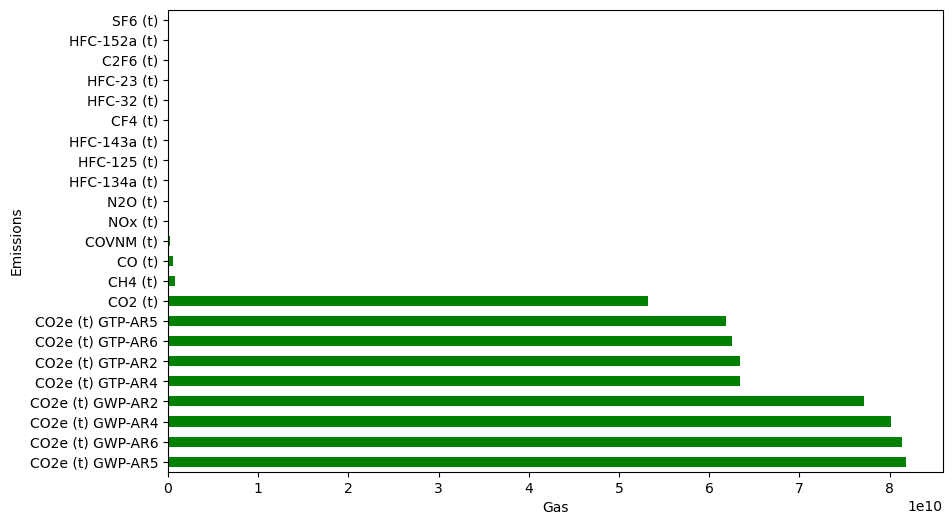

In [19]:
emisiones_totales_gas.plot(kind='barh', figsize=(10, 6), color='green', xlabel='Gas', ylabel='Emissions')

In [20]:
emisiones_totales_gas.iloc[0:9]

Gás
CO2e (t) GWP-AR5    8.181375e+10
CO2e (t) GWP-AR6    8.132316e+10
CO2e (t) GWP-AR4    8.015921e+10
CO2e (t) GWP-AR2    7.720596e+10
CO2e (t) GTP-AR4    6.344612e+10
CO2e (t) GTP-AR2    6.344612e+10
CO2e (t) GTP-AR6    6.247859e+10
CO2e (t) GTP-AR5    6.182200e+10
CO2 (t)             5.324636e+10
Name: Emissão, dtype: float64

In [21]:
(emisiones_totales_gas.iloc[0:9].sum()/emisiones_totales_gas.sum())*100

np.float64(99.73625255007093)

In [22]:
float(emisiones_totales_gas.iloc[0:9].sum()/emisiones_totales_gas.sum())*100

99.73625255007093

In [23]:
print(f'Las emisiones totales de CO2 son: {emisiones_totales_gas.iloc[0:9].sum()} y el porcentaje es: {float(emisiones_totales_gas.iloc[0:9].sum()/emisiones_totales_gas.sum())*100:.2f}%')

Las emisiones totales de CO2 son: 624941266633.5209 y el porcentaje es: 99.74%


> 
> ### Agrupamiento multi-index
> 
> Emision de gases por sector
> * Encotntrar dos informaciones:
>     - Sectores mas contaminantes por GAS
>     - Gases mas contaminantes por Sector
> 
> ---

In [24]:
df_emisiones_melted

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,Year,Emissão
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,COVNM (t),SP,OUTRA_IND,NaN,1970,0.0
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,N2O (t),SP,OUTRA_IND,NaN,1970,6210.0
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO (t),SP,OUTRA_IND,NaN,1970,368.0
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,NOx (t),SP,OUTRA_IND,NaN,1970,115.0
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO2e (t) GWP-AR2,SP,OUTRA_IND,NaN,1970,1925100.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4926891,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR5,MS,AGROPEC,NaN,2021,1004191.0
4926892,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MT,AGROPEC,NaN,2021,443120.0
4926893,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MS,AGROPEC,NaN,2021,1009968.0
4926894,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,N2O (t),MT,AGROPEC,NaN,2021,479.0


In [25]:
df_emisiones_melted.groupby(['Nível 1 - Setor','Gás']).sum(numeric_only = True)

Emissão
Nível 1 - Setor Gás                           
Agropecuária    CH4 (t)           5.928481e+08
                CO (t)            7.132479e+07
                CO2 (t)           5.411750e+08
                CO2e (t) GTP-AR2  8.297112e+09
                CO2e (t) GTP-AR4  8.297112e+09
...                                        ...
Resíduos        CO2e (t) GWP-AR2  1.769016e+09
                CO2e (t) GWP-AR4  2.081997e+09
                CO2e (t) GWP-AR5  2.310099e+09
                CO2e (t) GWP-AR6  2.233335e+09
                N2O (t)           2.764127e+05

[72 rows x 1 columns]

In [26]:
df_emisiones_melted.groupby(['Nível 1 - Setor','Gás']).sum(numeric_only = True).xs('CO2 (t)', level = 1) ## Cross-section xs() podemos selecciionar el que queremos y el nuvel de columna.

,Emissão
Nível 1 - Setor,
Agropecuária,5.411750e+08
Energia,1.261352e+10
Mudança de Uso da Terra e Floresta,3.733930e+10
Processos Industriais,2.729603e+09
Resíduos,2.276264e+07


In [27]:
df_emisiones_melted.groupby(['Nível 1 - Setor','Gás']).sum(numeric_only = True).xs(('CO2 (t)', 'Mudança de Uso da Terra e Floresta'), level = [1,0]).idxmax()

Emissão    (Mudança de Uso da Terra e Floresta, CO2 (t))
dtype: object

In [28]:
gas_sector = df_emisiones_melted.groupby(['Nível 1 - Setor','Gás']).sum(numeric_only = True)
gas_sector.groupby(level=1).idxmax()

,Emissão
Gás,
C2F6 (t),"(Processos Industriais, C2F6 (t))"
CF4 (t),"(Processos Industriais, CF4 (t))"
CH4 (t),"(Agropecuária, CH4 (t))"
CO (t),"(Energia, CO (t))"
CO2 (t),"(Mudança de Uso da Terra e Floresta, CO2 (t))"
CO2e (t) GTP-AR2,"(Mudança de Uso da Terra e Floresta, CO2e (t) ..."
CO2e (t) GTP-AR4,"(Mudança de Uso da Terra e Floresta, CO2e (t) ..."
CO2e (t) GTP-AR5,"(Mudança de Uso da Terra e Floresta, CO2e (t) ..."
CO2e (t) GTP-AR6,"(Mudança de Uso da Terra e Floresta, CO2e (t) ..."


In [29]:
gas_sector.groupby(level=1).max()

,Emissão
Gás,
C2F6 (t),5.765018e+02
CF4 (t),7.135481e+03
CH4 (t),5.928481e+08
CO (t),3.959769e+08
CO2 (t),3.733930e+10
CO2e (t) GTP-AR2,3.850044e+10
CO2e (t) GTP-AR4,3.850044e+10
CO2e (t) GTP-AR5,3.831675e+10
CO2e (t) GTP-AR6,3.843359e+10


In [30]:
gas_sector_valores = gas_sector.groupby(level=1).max().values
gas_sector_valores

array([[5.76501774e+02],
       [7.13548128e+03],
       [5.92848132e+08],
       [3.95976946e+08],
       [3.73393003e+10],
       [3.85004383e+10],
       [3.85004383e+10],
       [3.83167456e+10],
       [3.84335874e+10],
       [3.99942414e+10],
       [4.03083713e+10],
       [4.05152299e+10],
       [4.04921633e+10],
       [1.60862332e+08],
       [9.79558000e+03],
       [1.39473100e+05],
       [9.03940000e+03],
       [5.70600000e+02],
       [1.19784000e+03],
       [2.36775000e+03],
       [1.77470246e+07],
       [9.36121468e+07],
       [4.70580000e+02]])

In [31]:
tabla_gas_sector = gas_sector.groupby(level=1).idxmax()
tabla_gas_sector.insert(1, 'Total Emissão', gas_sector_valores)

In [32]:
tabla_gas_sector

,Emissão,Total Emissão
Gás,,
C2F6 (t),"(Processos Industriais, C2F6 (t))",5.765018e+02
CF4 (t),"(Processos Industriais, CF4 (t))",7.135481e+03
CH4 (t),"(Agropecuária, CH4 (t))",5.928481e+08
CO (t),"(Energia, CO (t))",3.959769e+08
CO2 (t),"(Mudança de Uso da Terra e Floresta, CO2 (t))",3.733930e+10
CO2e (t) GTP-AR2,"(Mudança de Uso da Terra e Floresta, CO2e (t) ...",3.850044e+10
CO2e (t) GTP-AR4,"(Mudança de Uso da Terra e Floresta, CO2e (t) ...",3.850044e+10
CO2e (t) GTP-AR5,"(Mudança de Uso da Terra e Floresta, CO2e (t) ...",3.831675e+10
CO2e (t) GTP-AR6,"(Mudança de Uso da Terra e Floresta, CO2e (t) ...",3.843359e+10


In [33]:
df_emisiones_melted.groupby(['Nível 1 - Setor','Gás']).sum(numeric_only = True)

Emissão
Nível 1 - Setor Gás                           
Agropecuária    CH4 (t)           5.928481e+08
                CO (t)            7.132479e+07
                CO2 (t)           5.411750e+08
                CO2e (t) GTP-AR2  8.297112e+09
                CO2e (t) GTP-AR4  8.297112e+09
...                                        ...
Resíduos        CO2e (t) GWP-AR2  1.769016e+09
                CO2e (t) GWP-AR4  2.081997e+09
                CO2e (t) GWP-AR5  2.310099e+09
                CO2e (t) GWP-AR6  2.233335e+09
                N2O (t)           2.764127e+05

[72 rows x 1 columns]

### Emision a lo largo de los Years

In [34]:
df_emisiones_melted

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,Year,Emissão
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,COVNM (t),SP,OUTRA_IND,NaN,1970,0.0
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,N2O (t),SP,OUTRA_IND,NaN,1970,6210.0
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO (t),SP,OUTRA_IND,NaN,1970,368.0
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,NOx (t),SP,OUTRA_IND,NaN,1970,115.0
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO2e (t) GWP-AR2,SP,OUTRA_IND,NaN,1970,1925100.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4926891,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR5,MS,AGROPEC,NaN,2021,1004191.0
4926892,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MT,AGROPEC,NaN,2021,443120.0
4926893,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MS,AGROPEC,NaN,2021,1009968.0
4926894,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,N2O (t),MT,AGROPEC,NaN,2021,479.0


In [35]:
df_emisiones_melted.groupby('Year').describe()

Emissão                                                        \
        count           mean           std            min       25%   
Year                                                                  
1970  94748.0   22127.818644  3.685560e+05       0.000000  0.000000   
1971  94748.0   23651.134813  3.886903e+05       0.000000  0.000000   
1972  94748.0   25177.219717  4.151800e+05       0.000000  0.000000   
1973  94748.0   27475.521366  4.560871e+05       0.000000  0.000000   
1974  94748.0   29196.398182  4.775896e+05       0.000000  0.000000   
1975  94748.0   31402.034191  5.132795e+05       0.000000  0.000000   
1976  94748.0   33663.406050  5.445755e+05       0.000000  0.000000   
1977  94748.0   34539.487677  5.358527e+05       0.000000  0.000000   
1978  94748.0   35947.683695  5.494819e+05       0.000000  0.000000   
1979  94748.0   37630.710596  5.648839e+05       0.000000  0.000000   
1980  94748.0   38862.349015  4.860424e+05       0.000000  0.000000   
1981  94748.0   37858.530578  4.783960e+05       0.000000  0.000000   
1982  94748.0   38208.648346  4.681901e+05       0.000000  0.000000   
1983  94748.0   37304.716375  4.577738e+05       0.000000  0.000000   
1984  94748.0   38224.142306  4.614876e+05       0.000000  0.000000   
1985  94748.0   39518.556049  4.665147e+05       0.000000  0.000000   
1986  94748.0   42046.899633  4.844134e+05       0.000000  0.000000   
1987  94748.0   43284.660323  4.882473e+05       0.000000  0.000000   
1988  94748.0   44274.269006  4.977109e+05       0.000000  0.000000   
1989  94748.0   45276.975566  4.982525e+05       0.000000  0.000000   
1990  94748.0  170952.039922  3.841235e+06       0.000000  0.000000   
1991  94748.0  171426.934093  3.614459e+06       0.000000  0.000000   
1992  94748.0  190460.200166  4.593049e+06      -7.000000  0.000000   
1993  94748.0  177246.067393  3.955521e+06  -27724.000000  0.000000   
1994  94748.0  199630.666650  5.133841e+06     -12.000000  0.000000   
1995  94748.0  228503.032722  6.540530e+06 -132530.000000  0.000000   
1996  94748.0  201598.016950  5.270165e+06      -1.000000  0.000000   
1997  94748.0  210630.879067  5.831644e+06     -37.000000  0.000000   
1998  94748.0  201263.600004  5.228749e+06     -25.000000  0.000000   
1999  94748.0  200267.570953  5.110843e+06     -92.000000  0.000000   
2000  94748.0  197525.478555  4.561102e+06    -140.000000  0.000000   
2001  94748.0  204008.384734  5.433951e+06    -121.000000  0.000000   
2002  94748.0  215635.594234  5.870641e+06    -162.000000  0.000000   
2003  94748.0  263347.006522  7.798506e+06     -89.000000  0.000000   
2004  94748.0  252487.405770  7.349825e+06       0.000000  0.000000   
2005  94748.0  220734.033051  5.675389e+06 -168890.912502  0.000002   
2006  94748.0  188608.910643  4.387208e+06 -199735.685921  0.000013   
2007  94748.0  166841.517391  3.295094e+06     -40.000000  0.016577   
2008  94748.0  166247.487564  3.118909e+06  -99095.143233  0.046540   
2009  94748.0  135724.827798  1.965378e+06       0.000000  0.049737   
2010  94748.0  135917.025777  1.629178e+06    -811.000000  0.043663   
2011  94748.0  139213.367473  1.596929e+06 -107707.331866  0.063673   
2012  94748.0  148947.236215  1.626753e+06  -91482.985296  0.075591   
2013  94748.0  163551.338924  1.885179e+06    -635.000000  0.063167   
2014  94748.0  158127.125723  1.760958e+06  -16513.059863  0.063325   
2015  94748.0  167872.197397  2.069217e+06     -98.000000  0.057176   
2016  94748.0  168719.202890  2.426642e+06     -58.000000  0.058678   
2017  94748.0  155680.268107  1.885514e+06    -116.000000  0.056541   
2018  94748.0  159538.813787  2.224893e+06      -1.000000  0.055507   
2019  94748.0  173924.696784  2.569499e+06      -8.000000  0.051503   
2020  94748.0  174542.408012  2.810139e+06     -45.000000  0.048145   
2021  94748.0  198423.244876  2.718336e+06      -1.000000  0.051248   

                                              
             50%           75%           max  
Year  

<Axes: xlabel='Year', ylabel='Emissions'>

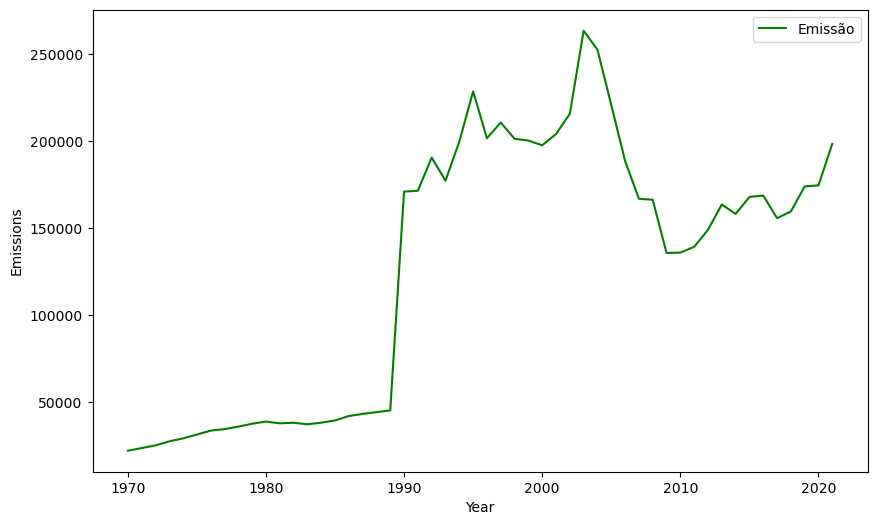

In [36]:
df_emisiones_melted.groupby('Year').mean(numeric_only = True).plot(figsize=(10, 6), color='green', xlabel='Year', ylabel='Emissions')

In [37]:
df_emisiones_melted.groupby('Year').mean(numeric_only = True)

,Emissão
Year,
1970,22127.818644
1971,23651.134813
1972,25177.219717
1973,27475.521366
1974,29196.398182
1975,31402.034191
1976,33663.406050
1977,34539.487677
1978,35947.683695


In [38]:
df_emisiones_melted.groupby('Year').mean(numeric_only = True).idxmax()  ## Year con mayor emision

Emissão    2003
dtype: int64

In [39]:
df_emisiones_melted.groupby(['Year','Gás']).mean(numeric_only = True)

Emissão
Year Gás                     
1970 C2F6 (t)        0.232610
     CF4 (t)         3.557421
     CH4 (t)      1471.024024
     CO (t)       2155.556658
     CO2 (t)     19244.913199
...                       ...
2021 HFC-23 (t)      0.000000
     HFC-32 (t)    261.100000
     N2O (t)       119.295311
     NOx (t)       679.395431
     SF6 (t)         5.240000

[1196 rows x 1 columns]

In [40]:
# Para grafiicar necesitamos una tabla de 3 columnas, no de con una columna doble.
df_emisiones_melted.groupby(['Year','Gás']).mean(numeric_only = True).reset_index()

,Year,Gás,Emissão
0,1970,C2F6 (t),0.232610
1,1970,CF4 (t),3.557421
2,1970,CH4 (t),1471.024024
3,1970,CO (t),2155.556658
4,1970,CO2 (t),19244.913199
...,...,...,...
1191,2021,HFC-23 (t),0.000000
1192,2021,HFC-32 (t),261.100000
1193,2021,N2O (t),119.295311
1194,2021,NOx (t),679.395431


In [41]:
promedio_emisiones = df_emisiones_melted.groupby(['Year','Gás']).mean(numeric_only = True).reset_index()
promedio_emisiones

,Year,Gás,Emissão
0,1970,C2F6 (t),0.232610
1,1970,CF4 (t),3.557421
2,1970,CH4 (t),1471.024024
3,1970,CO (t),2155.556658
4,1970,CO2 (t),19244.913199
...,...,...,...
1191,2021,HFC-23 (t),0.000000
1192,2021,HFC-32 (t),261.100000
1193,2021,N2O (t),119.295311
1194,2021,NOx (t),679.395431


In [42]:
promedio_emisiones_anual = promedio_emisiones.pivot_table(index='Year', columns='Gás', values='Emissão')

In [43]:
promedio_emisiones_anual

Gás,C2F6 (t),CF4 (t),CH4 (t),CO (t),CO2 (t),CO2e (t) GTP-AR2,CO2e (t) GTP-AR4,CO2e (t) GTP-AR5,CO2e (t) GTP-AR6,CO2e (t) GWP-AR2,...,COVNM (t),HFC-125 (t),HFC-134a (t),HFC-143a (t),HFC-152a (t),HFC-23 (t),HFC-32 (t),N2O (t),NOx (t),SF6 (t)
Year,,,,,,,,,,,,,,,,,,,,,
1970,0.232610,3.557421,1471.024024,2155.556658,19244.913199,20821.379814,20821.379814,19162.726020,19775.283385,35396.183865,...,742.074863,0.000000,0.000000,0.000000,0.0,0.00,0.00,31.632709,154.072797,0.000
1971,0.334611,5.117360,1525.506914,2259.625805,21598.587743,22466.288595,22466.288595,20748.481445,21386.175802,37570.982886,...,730.119047,0.000000,0.000000,0.000000,0.0,0.00,0.00,32.609237,170.550178,0.000
1972,0.404684,6.189025,1584.719568,2418.944795,23664.445521,24100.305265,24100.305265,22303.224240,22966.797327,39800.768350,...,774.278817,0.000000,0.000000,0.000000,0.0,0.00,0.00,34.311864,188.856161,0.000
1973,0.463147,7.083136,1642.612439,2596.053853,27726.668829,26683.827206,26683.827206,24827.077028,25516.409611,42947.755490,...,796.866394,0.000000,0.000000,0.000000,0.0,0.00,0.00,35.278689,217.320480,0.000
1974,0.471026,7.203619,1704.614365,2681.450599,30155.918952,28539.318732,28539.318732,26600.481407,27321.124852,45431.240064,...,1024.694923,0.000000,0.000000,0.000000,0.0,0.00,0.00,37.098183,247.521415,0.000
1975,0.502952,7.691893,1854.360821,2730.894830,32292.965771,30593.767465,30593.767465,28507.669059,29285.642221,48944.729581,...,1065.682750,0.000000,0.000000,0.000000,0.0,0.00,0.00,39.451008,262.716346,0.000
1976,0.577172,8.826970,1932.641716,2702.494362,35640.344723,33066.878007,33066.878007,30879.481709,31693.226162,52203.028009,...,1091.778909,0.000000,0.000000,0.000000,0.0,0.00,0.00,41.583225,287.013048,0.000
1977,0.692855,10.596169,1931.897645,2675.992077,37313.909077,34182.312333,34182.312333,31967.243034,32784.131397,53333.605735,...,1147.712448,0.000000,0.000000,0.000000,0.0,0.00,0.00,42.571086,292.405821,0.000
1978,0.749660,11.464915,1921.281930,2755.891877,40669.820049,35969.633601,35969.633601,33762.778999,34580.720998,55015.291182,...,1289.853564,0.000000,0.000000,0.000000,0.0,0.00,0.00,42.426649,322.982906,0.000


array([<Axes: xlabel='Year', ylabel='Emissions'>,
       <Axes: xlabel='Year', ylabel='Emissions'>,
       <Axes: xlabel='Year', ylabel='Emissions'>,
       <Axes: xlabel='Year', ylabel='Emissions'>,
       <Axes: xlabel='Year', ylabel='Emissions'>,
       <Axes: xlabel='Year', ylabel='Emissions'>,
       <Axes: xlabel='Year', ylabel='Emissions'>,
       <Axes: xlabel='Year', ylabel='Emissions'>,
       <Axes: xlabel='Year', ylabel='Emissions'>,
       <Axes: xlabel='Year', ylabel='Emissions'>,
       <Axes: xlabel='Year', ylabel='Emissions'>,
       <Axes: xlabel='Year', ylabel='Emissions'>,
       <Axes: xlabel='Year', ylabel='Emissions'>,
       <Axes: xlabel='Year', ylabel='Emissions'>,
       <Axes: xlabel='Year', ylabel='Emissions'>,
       <Axes: xlabel='Year', ylabel='Emissions'>,
       <Axes: xlabel='Year', ylabel='Emissions'>,
       <Axes: xlabel='Year', ylabel='Emissions'>,
       <Axes: xlabel='Year', ylabel='Emissions'>,
       <Axes: xlabel='Year', ylabel='Emissions'>,


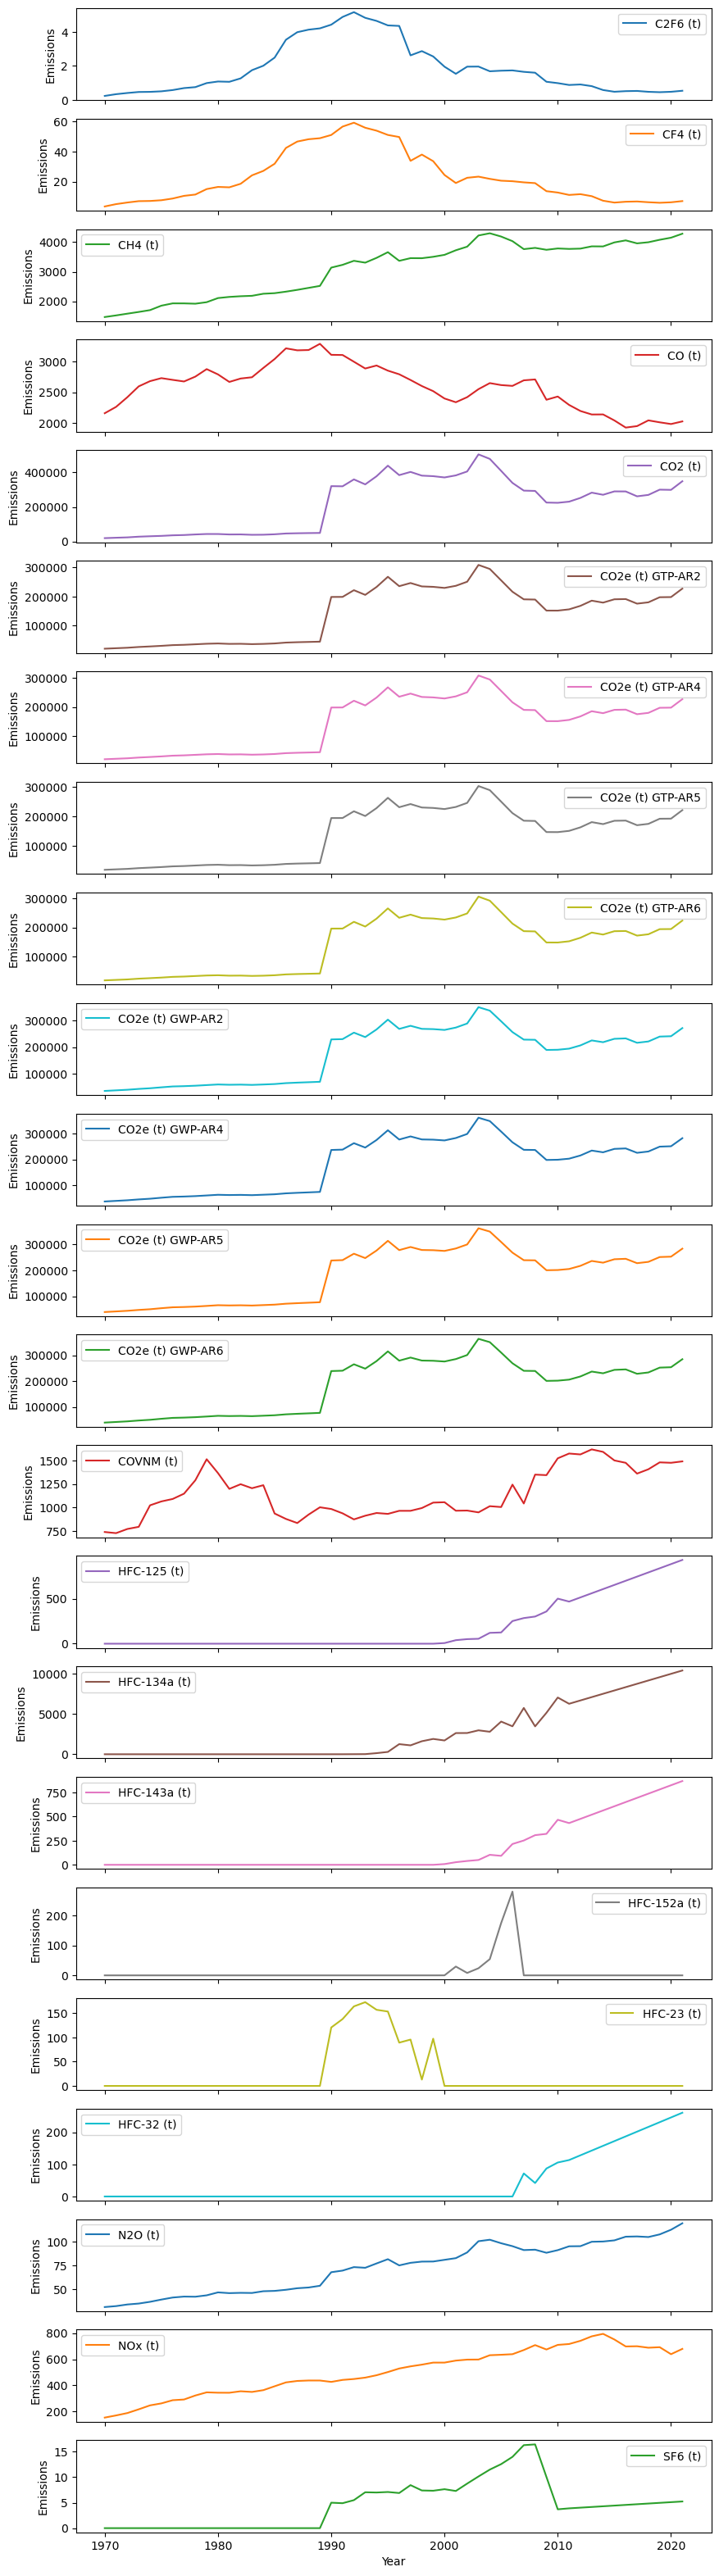

In [44]:
promedio_emisiones_anual.plot(subplots=True, figsize=(10, 40), xlabel='Year', ylabel='Emissions')

> ### Unir Datos
> Poblacion de los estados
> 
> Importar una DB con informacion poblacional y encontrar la emision percapita por estado.
> 
---
5572 - 1

In [45]:
df_poblacion = pd.read_excel('./POP2022_Municipios_20230622.xls', header=1, skipfooter=35)
df_poblacion.tail()

,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,POPULAÇÃO
5565,GO,52,22005,Vianópolis,14046
5566,GO,52,22054,Vicentinópolis,8776
5567,GO,52,22203,Vila Boa,3686
5568,GO,52,22302,Vila Propício,5646
5569,DF,53,108,Brasília,2923369


In [46]:
df_poblacion.groupby('UF').sum(numeric_only=True)

,COD. UF,COD. MUNIC
UF,,
AC,264,7719
AL,2754,487914
AM,806,134451
AP,256,5908
BA,12093,7151757
CE,4232,1295156
DF,53,108
ES,2496,226710
GO,12792,2788737


In [47]:
df_poblacion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5570 entries, 0 to 5569
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   UF                 5570 non-null   object
 1   COD. UF            5570 non-null   int64 
 2   COD. MUNIC         5570 non-null   int64 
 3   NOME DO MUNICÍPIO  5570 non-null   object
 4   POPULAÇÃO          5570 non-null   object
dtypes: int64(2), object(3)
memory usage: 217.7+ KB


In [48]:
df_poblacion['POPULAÇÃO'].astype(int)

ValueError: invalid literal for int() with base 10: '461.748(1)'

In [49]:
df_poblacion[df_poblacion['POPULAÇÃO'].str.contains('\(', na=False)]

,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,POPULAÇÃO
16,RO,11,205,Porto Velho,461.748(1)
74,AM,13,29,Alvarães,15.916(2)
81,AM,13,409,Barcelos,18.399(3)
83,AM,13,607,Benjamin Constant,37.436(4)
87,AM,13,805,Borba,33.209(5)
88,AM,13,839,Caapiranga,13.851(6)
97,AM,13,1605,Fonte Boa,27.692(7)
98,AM,13,1654,Guajará,13.809(8)
99,AM,13,1704,Humaitá,59.504(9)
102,AM,13,1902,Itacoatiara,103.826(31)


In [50]:
df_poblacion = df_poblacion.assign(sin_parentesis=df_poblacion['POPULAÇÃO'].replace('\(\d{1,2}\)', '', regex=True), 
                    poblacion = lambda x:x.loc[:,'sin_parentesis'].replace('\.','', regex=True))
df_poblacion[df_poblacion['POPULAÇÃO'].str.contains('\(', na=False)]

,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,POPULAÇÃO,sin_parentesis,poblacion
16,RO,11,205,Porto Velho,461.748(1),461.748,461748
74,AM,13,29,Alvarães,15.916(2),15.916,15916
81,AM,13,409,Barcelos,18.399(3),18.399,18399
83,AM,13,607,Benjamin Constant,37.436(4),37.436,37436
87,AM,13,805,Borba,33.209(5),33.209,33209
88,AM,13,839,Caapiranga,13.851(6),13.851,13851
97,AM,13,1605,Fonte Boa,27.692(7),27.692,27692
98,AM,13,1654,Guajará,13.809(8),13.809,13809
99,AM,13,1704,Humaitá,59.504(9),59.504,59504
102,AM,13,1902,Itacoatiara,103.826(31),103.826,103826


In [51]:
df_poblacion = df_poblacion.astype({'poblacion': 'int64'})
df_poblacion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5570 entries, 0 to 5569
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   UF                 5570 non-null   object
 1   COD. UF            5570 non-null   int64 
 2   COD. MUNIC         5570 non-null   int64 
 3   NOME DO MUNICÍPIO  5570 non-null   object
 4   POPULAÇÃO          5570 non-null   object
 5   sin_parentesis     5570 non-null   object
 6   poblacion          5570 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 304.7+ KB


In [52]:
df_poblacion_final = df_poblacion.groupby('UF')['poblacion'].sum().reset_index()

In [53]:
df_poblacion_final

,UF,poblacion
0,AC,829780
1,AL,3125254
2,AM,3952262
3,AP,774268
4,BA,14659023
5,CE,8936431
6,DF,2923369
7,ES,3975100
8,GO,6950976
9,MA,6800605


In [54]:
df_emisiones_melted['Year'] == 2021

0          False
1          False
2          False
3          False
4          False
           ...  
4926891     True
4926892     True
4926893     True
4926894     True
4926895     True
Name: Year, Length: 4926896, dtype: bool

In [55]:
df_emisiones_melted[df_emisiones_melted['Year'] == 2021]

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,Year,Emissão
4832148,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,COVNM (t),SP,OUTRA_IND,NaN,2021,897.600
4832149,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,N2O (t),SP,OUTRA_IND,NaN,2021,130.000
4832150,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO (t),SP,OUTRA_IND,NaN,2021,1380.576
4832151,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,NOx (t),SP,OUTRA_IND,NaN,2021,431.430
4832152,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO2e (t) GWP-AR2,SP,OUTRA_IND,NaN,2021,40300.000
...,...,...,...,...,...,...,...,...,...,...,...,...
4926891,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR5,MS,AGROPEC,NaN,2021,1004191.000
4926892,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MT,AGROPEC,NaN,2021,443120.000
4926893,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MS,AGROPEC,NaN,2021,1009968.000
4926894,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,N2O (t),MT,AGROPEC,NaN,2021,479.000


In [56]:
emsiones_estados = df_emisiones_melted[df_emisiones_melted['Year'] == 2021].groupby('Estado')[['Emissão']].sum().reset_index()
emsiones_estados

,Estado,Emissão
0,AC,3.505471e+08
1,AL,6.261279e+07
2,AM,1.189649e+09
3,AP,3.568410e+07
4,BA,5.932251e+08
5,CE,2.034731e+08
6,DF,5.668738e+07
7,ES,2.697547e+08
8,GO,6.008081e+08
9,MA,9.476324e+08


In [57]:
df_merged = pd.merge(emsiones_estados, df_poblacion_final, left_on='Estado', right_on='UF')
df_merged

,Estado,Emissão,UF,poblacion
0,AC,3.505471e+08,AC,829780
1,AL,6.261279e+07,AL,3125254
2,AM,1.189649e+09,AM,3952262
3,AP,3.568410e+07,AP,774268
4,BA,5.932251e+08,BA,14659023
5,CE,2.034731e+08,CE,8936431
6,DF,5.668738e+07,DF,2923369
7,ES,2.697547e+08,ES,3975100
8,GO,6.008081e+08,GO,6950976
9,MA,9.476324e+08,MA,6800605


<Axes: xlabel='poblacion', ylabel='Emissão'>

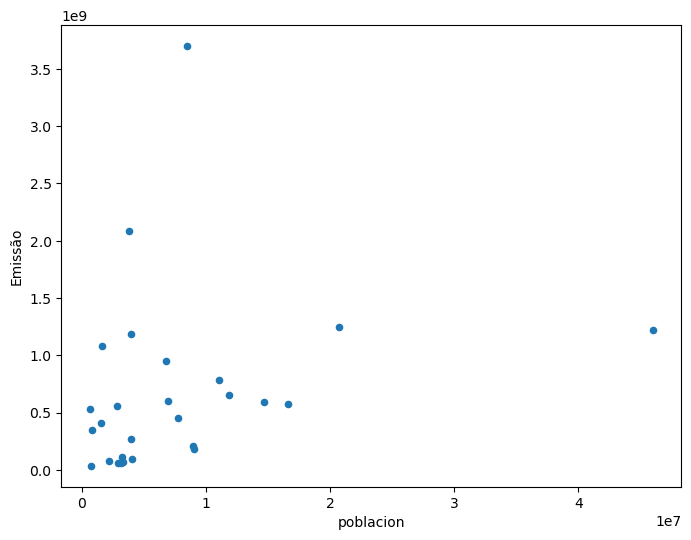

In [58]:
df_merged.plot(kind='scatter', x='poblacion', y='Emissão', figsize=(8,6))

In [59]:
import plotly.express as px
px.scatter(df_merged, x="poblacion", y="Emissão", color="Estado", text='UF', size_max=60, opacity=0) 


In [60]:
df_merged

,Estado,Emissão,UF,poblacion
0,AC,3.505471e+08,AC,829780
1,AL,6.261279e+07,AL,3125254
2,AM,1.189649e+09,AM,3952262
3,AP,3.568410e+07,AP,774268
4,BA,5.932251e+08,BA,14659023
5,CE,2.034731e+08,CE,8936431
6,DF,5.668738e+07,DF,2923369
7,ES,2.697547e+08,ES,3975100
8,GO,6.008081e+08,GO,6950976
9,MA,9.476324e+08,MA,6800605


In [ ]:
df_merged = df_merged.assign(emision_per_capita=df_merged['Emissão']/df_merged['poblacion']).sort_values('emision_per_capita', ascending=False)
df_merged

,Estado,Emissão,UF,poblacion,emision_per_capita
21,RR,5.282071e+08,RR,634805,832.077694
20,RO,1.083515e+09,RO,1616379,670.334662
12,MT,2.081610e+09,MT,3784239,550.073647
13,PA,3.701684e+09,PA,8442962,438.434230
0,AC,3.505471e+08,AC,829780,422.457928
2,AM,1.189649e+09,AM,3952262,301.004463
26,TO,4.082159e+08,TO,1584306,257.662300
11,MS,5.551278e+08,MS,2833742,195.899220
9,MA,9.476324e+08,MA,6800605,139.345312
8,GO,6.008081e+08,GO,6950976,86.435075


In [68]:
px.bar(df_merged, x='Estado', y='emision_per_capita', text='emision_per_capita', opacity=0.8, title='Emissão por Estado', width=800, height=600)

In [67]:
px.scatter(df_merged, x="poblacion", y="Emissão", color="Estado", text='UF', size_max=60, size='emision_per_capita') 